In [1]:
from dotenv import load_dotenv, find_dotenv
import os

load_dotenv(find_dotenv())
token = os.getenv("KAGGLE_API_TOKEN")

# !kaggle competitions download -c traffic-sign-object-detection-challenge
# !unzip traffic-sign-object-detection-challenge.zip

In [2]:
from utils.data import convert_coco_to_yolo, generate_yolo_yaml
from utils.inference import run_inference
from utils.viz import visualize_predictions
from utils.train import train_yolo_model
import pandas as pd

In [3]:
infer_class_map = convert_coco_to_yolo(
    ann_path="dataset/train/annotations.json", 
    img_src_dir="dataset/train/images", 
    yolo_base_dir="dataset/obj"
)
generate_yolo_yaml("data.yaml", "dataset/obj", infer_class_map)

In [ ]:
base_cfg = {
    "data_yaml": "data.yaml",
    "epochs": 32,
    "imgsz": 640,
    "batch": 16,
    "patience": 8,
    "amp": True,
    "device": 0
}

EPOCHS = base_cfg['epochs']
MODEL_VARIANT = "yolo26n"
EXPERIMENT_NAME = f"traffic-sign-{MODEL_VARIANT}-{EPOCHS}"

In [ ]:
train_yolo_model(
    model_variant=f"{MODEL_VARIANT}.pt", 
    experiment_name=EXPERIMENT_NAME,
    **base_cfg
)

In [ ]:
results = run_inference(
    model_path=f"runs/detect/{EXPERIMENT_NAME}/weights/best.pt",
    test_dir="dataset/test/images",
    class_names=infer_class_map
)

In [ ]:
df = pd.DataFrame(results)
df.to_csv(f"submissions/submission-{EXPERIMENT_NAME}.csv", index=False)

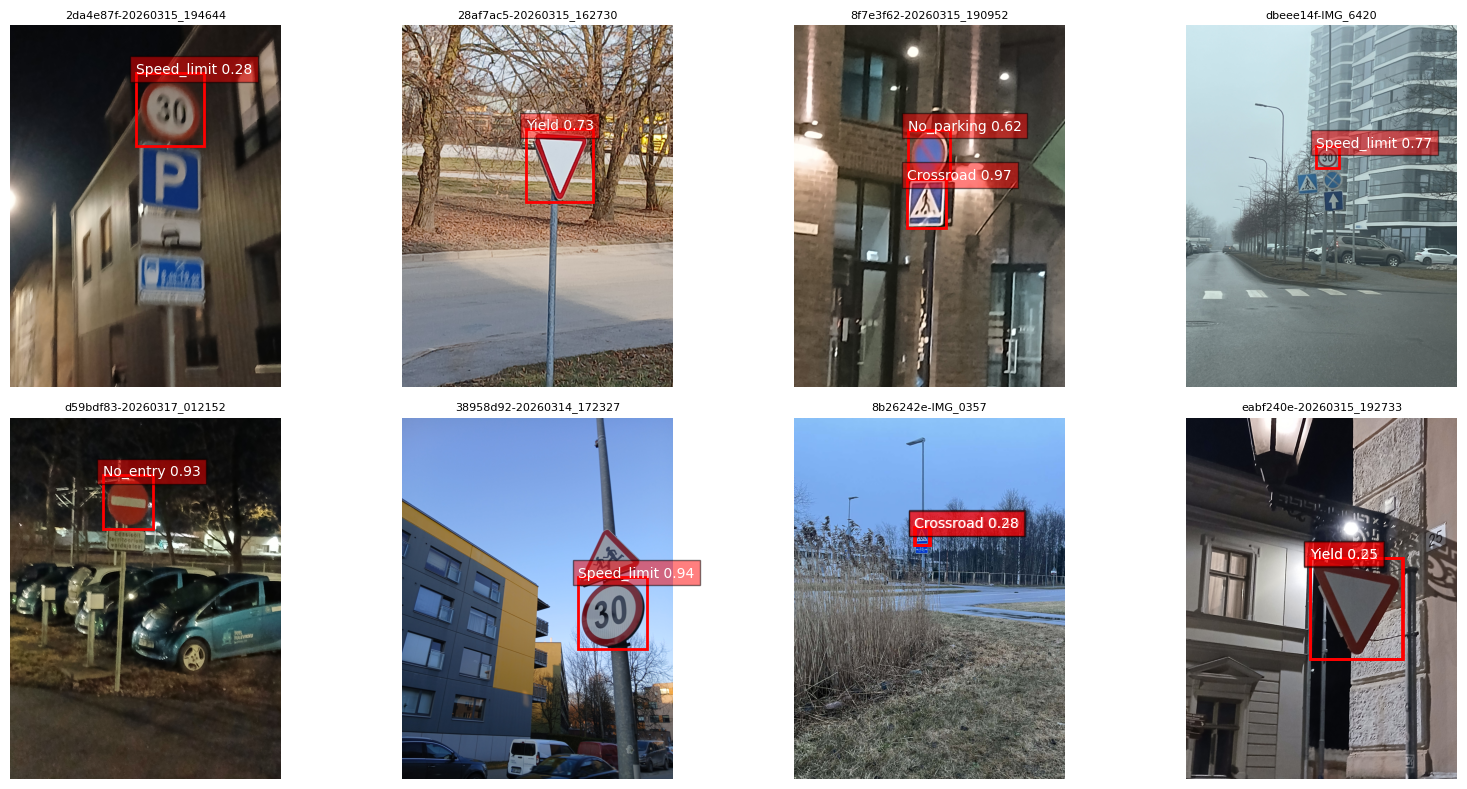

In [15]:
%matplotlib inline
visualize_predictions(results, "dataset/test/images", infer_class_map)

## RT-DETR — transformer-based detection

RT-DETR (Real-Time Detection Transformer) replaces the CNN backbone + anchor-based head with a transformer encoder-decoder. Unlike YOLO, it uses attention to reason globally over the image rather than sliding-window convolutions, making it better at context-dependent detections. Ultralytics ships `rtdetr-l.pt`, so the training API is identical.

In [5]:
rtdetr_cfg = {
    "data_yaml": "data.yaml",
    "epochs": 50,
    "imgsz": 640,
    "batch": 8,
    "patience": 15,
    "amp": True,
    "device": 0,
}

RTDETR_NAME = "traffic-sign-rtdetr-l"

In [ ]:
train_yolo_model(
    model_variant="rtdetr-l.pt",
    experiment_name=RTDETR_NAME,
    **rtdetr_cfg
)

In [ ]:
from ultralytics import RTDETR

model = RTDETR(f"runs/detect/{RTDETR_NAME}/weights/last.pt")
model.train(resume=True)

In [7]:
results_rtdetr = run_inference(
    model_path=f"runs/detect/{RTDETR_NAME}/weights/best.pt",
    test_dir="dataset/test/images",
    class_names=infer_class_map
)

df_rtdetr = pd.DataFrame(results_rtdetr)
df_rtdetr.to_csv(f"submissions/submission-{RTDETR_NAME}.csv", index=False)
df_rtdetr.head()

Inference: 100%|█████████████████████████████████████████████████████████████████████████████| 167/167 [00:20<00:00,  8.18it/s]


,image_id,PredictionString
0,00ee5e76-IMG_1151,Crossroad 0.8347 1315.8606 2349.9504 1543.3423...
1,03eb5449-20260313_172307,No_stopping 0.7305 1601.0699 1621.0974 1802.16...
2,06386722-IMG_6428,No_stopping 0.8303 1449.1688 1603.1421 1924.05...
3,08ca7d8d-20260315_194633,Speed_limit 0.8998 484.4092 969.1509 1341.7694...
4,08e35074-20260315_192453,Bus_stop 0.9164 1097.8038 1098.7855 2032.7758 ...
